# **Seleção e ajuste de modelos**

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

Em muitos métodos de classificação e regressão, precisamos definir os valores do hiperparâmetros dos modelos, que são parâmetros ajustados pelo usuário. Exemplos desses métodos são o algoritmo k-vizinhos, onde precisamos definir o valor $k$, e o número de árvores no algoritmo florestas aleatórias. No caso de regressão, o desafio é identificar as variáveis significativas.

### Classificação

Se dividirmos o conjunto de dados em apenas duas partes, uma teste e outra para treinamento, método chamado **holdout**, depedendo da execução do classificador, podemos obter diferentes resultos. A seguir, mostramos o desempenho do classificar knn de acordo com a execução. Notem que os valores se distribuem de acordo com uma distribuição de probabilidades que se aproxima e uma distribuição Gaussiana.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   Comp  Circ  D.Circ  Rad.Ra  Pr.Axis.Ra  Max.L.Ra  Scat.Ra  Elong  \
0    95    48      83     178          72        10      162     42   
1    91    41      84     141          57         9      149     45   
2   104    50     106     209          66        10      207     32   
3    93    41      82     159          63         9      144     46   
4    85    44      70     205         103        52      149     45   

   Pr.Axis.Rect  Max.L.Rect  Sc.Var.Maxis  Sc.Var.maxis  Ra.Gyr  Skew.Maxis  \
0            20         159           176           379     184          70   
1            19         143           170           330     158          72   
2            23         158           223           635     220          73   
3            19         143           160           309     127          63   
4            19         144           241      

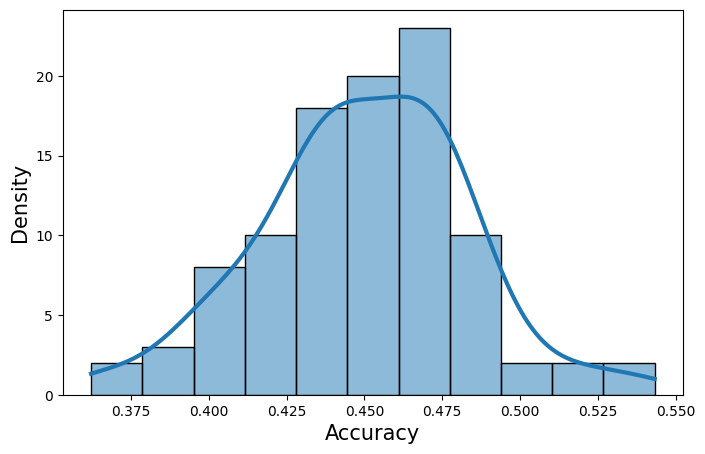

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import seaborn as sns

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################


data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

p = 0.7 # fracao de elementos no conjunto de treinamento
Ns = 100 # numero de execucoes da classificacao
vacc = []
for n in range(0, Ns):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p)

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = accuracy_score(y_pred, y_test)
    vacc.append(score)
print('Acuracia media:', np.mean(vacc))
plt.figure(figsize=(8,5))
#sns.distplot(vacc, hist = True, kde = True,kde_kws = {'linewidth': 3})
sns.histplot(vacc, kde = True, line_kws = {'linewidth': 3})
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.xlabel('Accuracy', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.show(True)

Portanto, podemos ter uma alta ou baixa acurácia, dependendo da execução.

Além disso, a escolha dos hiperparâmetros do modelo também é influenciada pela execução. Vamos considerar um exemplo. No classificador k-vizinhos, o hiperparâmetro $k$ influencia na classificação e a escolha do melhor valor de $k$ pode depender da execução se usar o método hold-out, conforme vemos a seguir.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   Comp  Circ  D.Circ  Rad.Ra  Pr.Axis.Ra  Max.L.Ra  Scat.Ra  Elong  \
0    95    48      83     178          72        10      162     42   
1    91    41      84     141          57         9      149     45   
2   104    50     106     209          66        10      207     32   
3    93    41      82     159          63         9      144     46   
4    85    44      70     205         103        52      149     45   

   Pr.Axis.Rect  Max.L.Rect  Sc.Var.Maxis  Sc.Var.maxis  Ra.Gyr  Skew.Maxis  \
0            20         159           176           379     184          70   
1            19         143           170           330     158          72   
2            23         158           223           635     220          73   
3            19         143           160           309     127          63   
4            19         144           241      

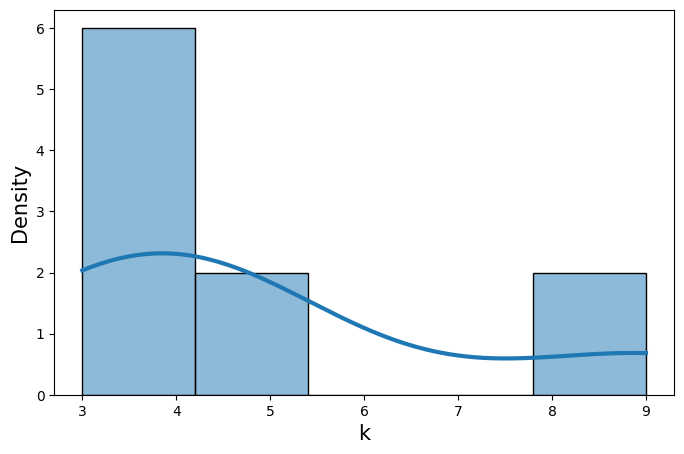

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

#data = pd.read_csv('data/Iris.csv', header=(0))

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

p = 0.7 # fracao de elementos no conjunto de treinamento
Ns = 10 # numero de execucoes da classificacao
vk = []
for n in range(0, Ns):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p)

    vbest = []
    for k in range(1, 10):
        model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_pred, y_test)
        vbest.append(score)
    vk.append(np.argmax(vbest)+1)

plt.figure(figsize=(8,5))
sns.histplot(vk, kde = True, line_kws = {'linewidth': 3})
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.xlabel('k', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.show(True)

Portanto, dependendo da execução, podemos encontrar um valor diferente para $k$, de modo a obter a melhor acurácia. Logo, não podemos obter o melhor modelo de uma maneira adequada.

Para evitarmos essa dependência da execução e diminuirmos a variância, podemos usar os métodos de validação cruzada.

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
random.seed(42) # define the seed (important to reproduce the results)

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

data.head(10)

nrow, ncol = data.shape
attributes = list(data.columns)


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   Comp  Circ  D.Circ  Rad.Ra  Pr.Axis.Ra  Max.L.Ra  Scat.Ra  Elong  \
0    95    48      83     178          72        10      162     42   
1    91    41      84     141          57         9      149     45   
2   104    50     106     209          66        10      207     32   
3    93    41      82     159          63         9      144     46   
4    85    44      70     205         103        52      149     45   

   Pr.Axis.Rect  Max.L.Rect  Sc.Var.Maxis  Sc.Var.maxis  Ra.Gyr  Skew.Maxis  \
0            20         159           176           379     184          70   
1            19         143           170           330     158          72   
2            23         158           223           635     220          73   
3            19         143           160           309     127          63   
4            19         144           241      

In [ ]:
from sklearn.model_selection import KFold

# validação cruzada
cv = KFold(n_splits=10)
vacc = []
for train_index, test_index in cv.split(X, y):
    x_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = GaussianNB()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    score = accuracy_score(y_pred, y_test)
    vacc.append(score)
print('Acuracia media:', np.mean(vacc))

Acuracia media: 0.4632212885154062


Notem que mesmo que executemos o código várias vezes, obtemos sempre aproximadamente a mesma acurácia.

In [ ]:
from sklearn.model_selection import KFold

for i in range(0,5):
    cv = KFold(n_splits=10)
    vacc = []
    for train_index, test_index in cv.split(X, y):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        model = GaussianNB()
        model.fit(x_train,y_train)
        y_pred = model.predict(x_test)
        score = accuracy_score(y_pred, y_test)
        vacc.append(score)
    print('Acuracia media:', np.mean(vacc))

Acuracia media: 0.4632212885154062
Acuracia media: 0.4632212885154062
Acuracia media: 0.4632212885154062
Acuracia media: 0.4632212885154062
Acuracia media: 0.4632212885154062


Caso os dados sejam desbalanceado, podemos usar ainda a validação cruzada estratificada.

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

vacc = []
for train_index, test_index in cv.split(X, y):
    x_train, x_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model = GaussianNB()
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    score = accuracy_score(y_pred, y_test)
    vacc.append(score)
print('Acuracia media:', np.mean(vacc))

Acuracia media: 0.4561484593837535


Para escolhermos os melhores hiperparâmetros do modelo usando validação cruzada, podemos usar o método GridSearch da biblioteca sckit-learn.

In [ ]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors': [1,2,3,4,5,6,7,8,9,10]}
model = KNeighborsClassifier(metric = 'euclidean')
best_model = GridSearchCV(model, parameters, cv = 10)
best_model.fit(X,y)
y_pred = best_model.predict(X)
print('Best parameters:', best_model.best_params_)
print('Accuracy:', accuracy_score(y_pred, y))

Best parameters: {'n_neighbors': 3}
Accuracy: 0.8085106382978723


Essa mesma execução pode ser executada com o código abaixo. Portanto, o método GridSearch automatiza o processo.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


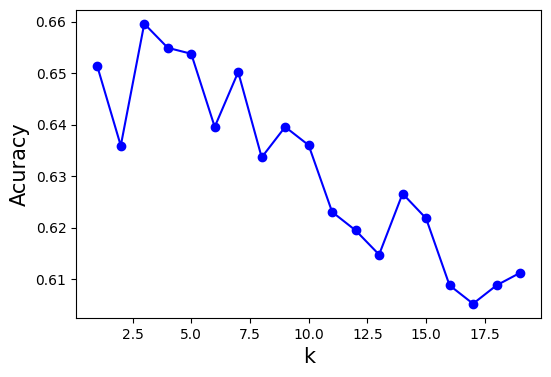

Melhor k: 3
Accuracy: 0.8085106382978723


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    #print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

nkf = 10 #number of folds
vk = [] # armazena os valores de k
vscore = []
for k in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
    # realiza a validação cruzada
    cv = cross_validate(model, X, y, cv=nkf)
    vscore.append(cv['test_score'].mean())
    vk.append(k)

plt.figure(figsize=(6,4))
plt.plot(vk, vscore, '-bo')
plt.xlabel('k', fontsize = 15)
plt.ylabel('Acuracy', fontsize = 15)
plt.show(True)
best_k = np.argmax(vscore)+1
print('Melhor k:', best_k)
best_model = KNeighborsClassifier(n_neighbors=best_k, metric = 'euclidean')
best_model.fit(X,y)
y_pred = best_model.predict(X)
print('Accuracy:', accuracy_score(y_pred, y))

# Treinamento e teste

Notem que nos exemplos anteriores, ainda não dividimos os dados em teste e treinamento. Usamos todo o cojunto de dados como treinamento. No entanto, na prática, devemos inicialmente separar os dados em dois conjuntos. Mas notem que a escolha do conjunto de teste está relacionado com o mesmo problema anterior, dependendo da execução, conforme vemos a seguir.

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Acuracia media: 0.6485294117647058


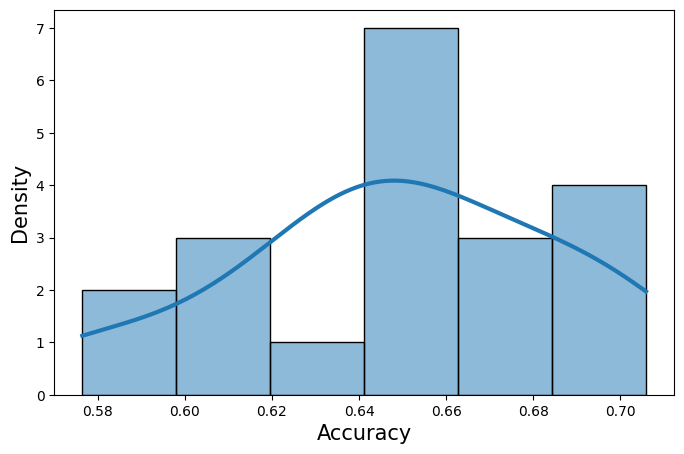

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    #print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################


data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Ns = 20 #number of executions
vacc = []
for n in range(0,Ns):
    p = 0.8 # fracao de elementos no conjunto de treinamento
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p)

    parameters = {'n_neighbors': [1,2,3,4,5,6,7,8,9,10]}
    model = KNeighborsClassifier(metric = 'euclidean')
    best_model = GridSearchCV(model, parameters, cv = 10)
    best_model.fit(X_train,y_train)
    y_pred = best_model.predict(X_test)
    #print('Best parameters:', grid.best_params_)
    #print('Accuracy:', accuracy_score(y_pred, y_test))
    vacc.append(accuracy_score(y_pred, y_test))

print('Acuracia media:', np.mean(vacc))
plt.figure(figsize=(8,5))
#sns.distplot(vacc, hist = True, kde = True,kde_kws = {'linewidth': 3})
sns.histplot(vacc, kde = True, line_kws = {'linewidth': 3})
plt.xticks(color='k', size=10)
plt.yticks(color='k', size=10)
plt.xlabel('Accuracy', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.show(True)

Para resolver essa limitação com relação à seleção conjunto de teste, podemos considerar o método de validação cruzada aninhada (nested cross validation). A seguir, implementamos uma função para utilizar esse método.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

def classification_nested_crossvalidation(X, y, n_folds,k_folds, model, hp_grid):
    # define the external cross validation
    cv_outer = KFold(n_folds, shuffle=True)
    vacc = list()
    # CV external lood
    for train_out, test_out in cv_outer.split(X):
        train_x, train_y = X[train_out], y[train_out]
        test_x, test_y = X[test_out], y[test_out]
        # internal CV (training and validation sets)
        grid_search_cv = GridSearchCV(model, hp_grid, cv=k_folds, refit=True)
        # find the best hyperparameters
        result = grid_search_cv.fit(train_x, train_y)
        best_model = result.best_estimator_
        # prediction in the test fold
        pred_y = best_model.predict(test_x)
        vacc.append(accuracy_score(test_y, pred_y))
    return np.mean(vacc), np.std(vacc)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    #print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

n_folds = 5 # cv external folds
k_folds = 10 # cv internal folds (training set)
parameters = {'n_neighbors':range(1,10)}
model = KNeighborsClassifier()
av_acc,std_acc = classification_nested_crossvalidation(X, y, n_folds,
                                                       k_folds, model,parameters)
print('Accuracy:', av_acc, 'std:', std_acc)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Accuracy: 0.6276714235990255 std: 0.024337810149111783


Assim, podemos fazer a seleção do modelo de forma que os resultados não dependam da execução. Em resumo, o método de validação cruzada aninhada permite reduzir a variância e selecionar os melhores hiperparâmetros dos modelos.

## Seleção do modelo usando grid_search no knn

Ver: https://scikit-learn.org/stable/modules/grid_search.html

É possível escolhermos os hiperparâmetros de um modelo usando o método grid_search da biblioteca sklearn. Vamos inicialmente ler os dados e separar os conjuntos de treinamento e teste.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import seaborn as sns

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    #print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Para realizar o grid_search, precisamos definir quais hiperparâmetros serão considerados e os valores que serão testados.

In [ ]:
grid_params = { 'n_neighbors' : [5,7,9,11,13,15],
               'weights' : ['uniform','distance'],
               'metric' : ['minkowski','euclidean','manhattan']}

Podemos então chamar o método. Notem que já fazemos a validação cruzada.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

gs = GridSearchCV(KNeighborsClassifier(), grid_params, verbose = 1, cv=3, n_jobs = -1)

Aplicamos aos conjuntos de dados e treinamento.

In [ ]:
# fit the model on our train set
g_res = gs.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


A acurácia do método:

In [ ]:
print("Acurácia: ", g_res.best_score_)

Acurácia:  0.68836291913215


Os melhores hiperparâmetros identificados para obter essa melhor acurácia:

In [ ]:
print("Melhores hiperparâmetros: ", g_res.best_params_)

Melhores hiperparâmetros:  {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


Finalmente, voltamos a ajustar o modelo, mas agora com os melhores hiperparâmetros:

In [ ]:
# use the best hyperparameters
knn = KNeighborsClassifier(n_neighbors = 5, weights = 'uniform',algorithm = 'brute',metric = 'minkowski')
knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='brute')

Fazmos a precição e calculamos a acurácia com esses melhores hiperparâmetros:

In [ ]:
# get a prediction
y_hat = knn.predict(X_train)
y_knn = knn.predict(X_test)

print('Training set accuracy: ', metrics.accuracy_score(y_train, y_hat))
print('Test set accuracy: ',metrics.accuracy_score(y_test, y_knn))

Training set accuracy:  0.777120315581854
Test set accuracy:  0.6135693215339233


## Seleção do modelo usando grid_search na árvore de decisão

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import seaborn as sns

# se for lear do hard disk: ############################
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/Iris.csv', header=(0))

# Se for lear do Google Drive: ############################
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/data/Vehicle.csv'
try:
    data = pd.read_csv(file_path)
    #print(data.head()) # Print the first 5 rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
############################

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Para realizar o grid_search, precisamos definir quais hiperparâmetros serão considerados e os valores que serão testados.

In [ ]:
grid_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Define grid_params (already defined in cell aTPUcoe7Q5-U, but including it here for completeness if that cell wasn't run)
grid_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

# Initialize GridSearchCV
gs_dt = GridSearchCV(dt_model, grid_params, verbose=1, cv=3, n_jobs=-1)

# Fit the model on the training data
gs_dt.fit(X_train, y_train)

# Print the best accuracy and best hyperparameters
print("Melhor acurácia (média da validação cruzada):", gs_dt.best_score_)
print("Melhores hiperparâmetros:", gs_dt.best_params_)

# Optional: Evaluate on the test set using the best estimator
best_dt_model = gs_dt.best_estimator_
y_pred_test = best_dt_model.predict(X_test)
print("Acurácia no conjunto de teste com os melhores hiperparâmetros:", accuracy_score(y_test, y_pred_test))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Melhor acurácia (média da validação cruzada): 0.700197238658777
Melhores hiperparâmetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2}
Acurácia no conjunto de teste com os melhores hiperparâmetros: 0.6696165191740413


## Exercícios para entregar

1 - Realize a classificação da base winequality-red usando validação cruzada e o método grid_search para escolher os melhores hiperparâmetros do modelo árvore de decisão e knn

2 - Verifique se o número de folds, usado na validação cruzada, influencia na classificação da base winequality-red. Use o classificador Naive Bayes.

3 - Use validação cruzada para escolher o melhor valor de h no classificador bayesiano não paramétrico. Use a base Vehicle.